Creates Figure 2 of the main paper

In [1]:
#load packages needed in this notebook
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from eofs.standard import Eof
import regionmask
import cartopy.crs as ccrs
from matplotlib import pyplot as PP
import copy
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/nmaher/.conda/envs/clara/share/proj failed


In [2]:
#define models and the start year of simulations
models_title=['CESM2','CESM1','ACCESS','CanESM5','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

#tell me when the start year is 
syear=[1850,1920,1850,1850,1921,1850,1850,1850]
#offset=1920-syear

#load lon lat should be same for all models
outputdira='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
ds_fx = xr.open_dataset(outputdira+'zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat


In [3]:
#load data
outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'


In [4]:
cdataE_tot=np.zeros([8,72,145])
cdataL_tot=np.zeros([8,72,145])
cdataEM_tot=np.zeros([8,72,145])
cdataLM_tot=np.zeros([8,72,145])

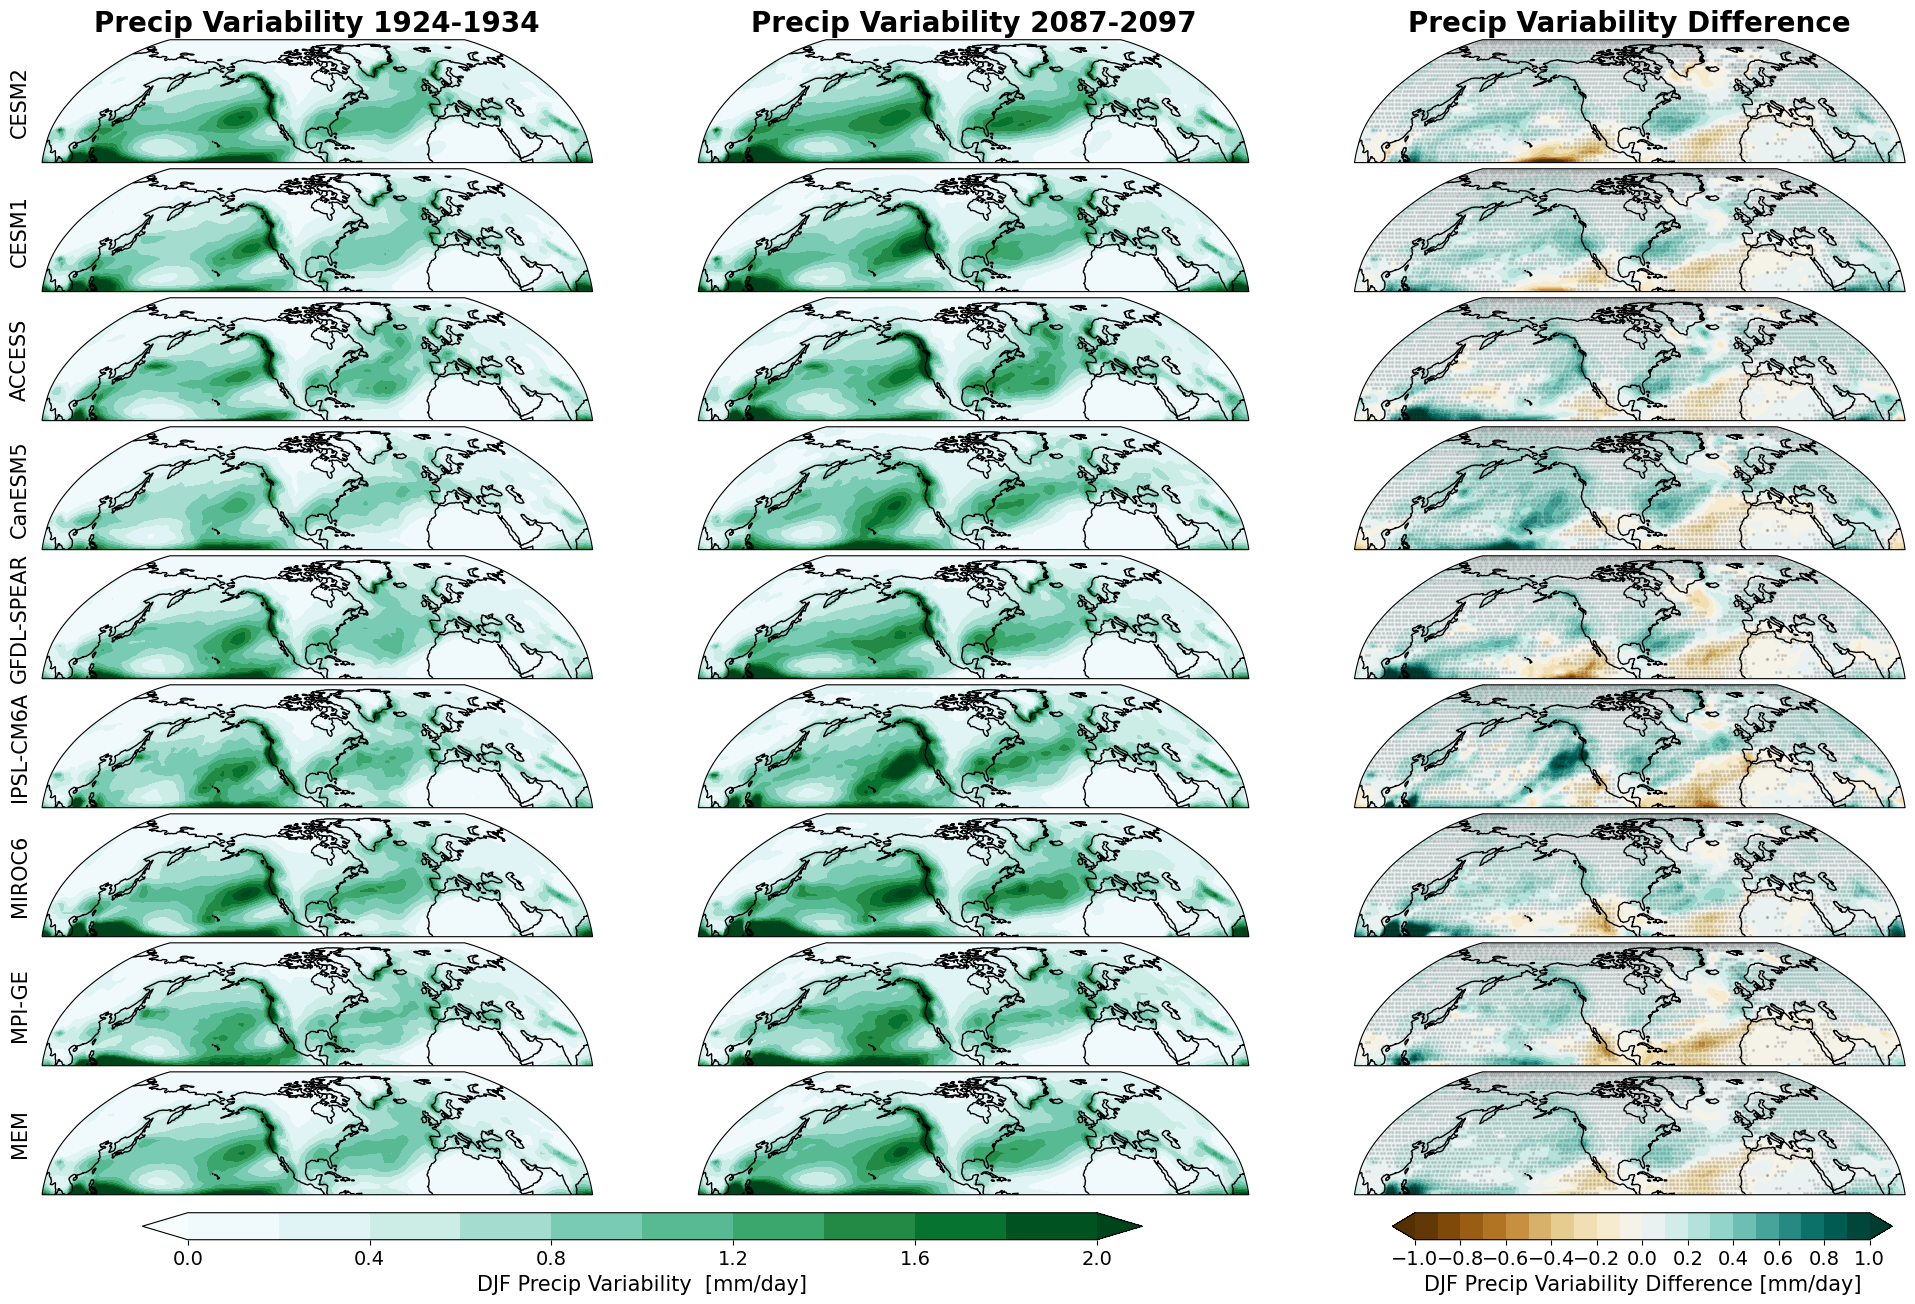

In [5]:
#plot data
fig,axs = PP.subplots(9,3,figsize=(25,15), subplot_kw={'projection': ccrs.Robinson(central_longitude=270)})

levelsM = np.linspace(-1,1,21)
clevelsM = np.linspace(-1,1,21)

clevels = np.linspace(0,2,21)
levels = np.linspace(0,2,11)
e=[-180, 180,10,90]


cmap = copy.deepcopy(mpl.cm.cividis)
cmap = copy.deepcopy(mpl.cm.magma)
cmap = copy.deepcopy(mpl.cm.BuGn)


cmapM = copy.deepcopy(mpl.cm.BrBG)





# define 2d lat and lon points for ploting sig locs
lons=lon
lats=lat
lon2d,lat2d = np.meshgrid(lons,lats)

s2=np.zeros([8,72,145])


ii=-1
for model in models:
    ii=ii+1
    offset=1921-syear[ii]

    outputdir2='/glade/work/nmaher/SEOF_output/'

    eof_T='_prDJF'
    with np.load(outputdir2+model+eof_T+'_SEOF.npz') as npz:
        zg = np.ma.MaskedArray(**npz)*86400

    cnt=0
    if model=='CESM2':
        zg=zg*1000

    

    # grab early data
    zg2a=zg[:,0+offset:10+offset,:,:]
    zg2b=zg[:,164+offset:174+offset,:,:]
    zg3a=zg2a.var(axis=0)
    zg3b=zg2b.var(axis=0)
    zg4a=zg2a.mean(axis=0)
    zg4b=zg2b.mean(axis=0)
    
    
    cdataE,clons = add_cyclic_point(zg3a.mean(axis=0),lons)
    cdataL,clons = add_cyclic_point(zg3b.mean(axis=0),lons)
    cdataEM,clons = add_cyclic_point(zg4a.mean(axis=0),lons)
    cdataLM,clons = add_cyclic_point(zg4b.mean(axis=0),lons)

    #plot difference in colour and early in contours
    cplt = axs[ii,0].contourf(clons,lats,np.sqrt(cdataE), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extent=e, extend='both')   
    #cpltc = axs[ii,0].contour(clons,lats,cdataEM, transform=ccrs.PlateCarree(), levels=clevels, extent=e, colors='k', linewidths=1.0)

    cplt = axs[ii,1].contourf(clons,lats,np.sqrt(cdataL), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extent=e, extend='both')   
    #cpltc = axs[ii,1].contour(clons,lats,cdataLM, transform=ccrs.PlateCarree(), levels=clevels, extent=e, colors='k', linewidths=1.0)

    s=np.sqrt(cdataL)-np.sqrt(cdataE)
    s2[ii]=np.where(s > 0, 1, 0)
    
    cplt = axs[ii,2].contourf(clons,lats,np.sqrt(cdataL)-np.sqrt(cdataE), transform=ccrs.PlateCarree(), levels=levelsM, cmap=cmapM, extent=e, extend='both')   
    #cpltc = axs[ii,2].contour(clons,lats,cdataLM-cdataEM, transform=ccrs.PlateCarree(), levels=clevelsM, extent=e, colors='k', linewidths=1.0)

    for i in range(3):
        axs[ii,i].coastlines()
        axs[ii,i].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())

    cdataE_tot[ii,:,:]=cdataE
    cdataL_tot[ii,:,:]=cdataL
    cdataEM_tot[ii,:,:]=cdataEM
    cdataLM_tot[ii,:,:]=cdataLM
    
    
ii=8
#plot difference in colour and early in contours
cplt = axs[ii,0].contourf(clons,lats,np.sqrt(cdataE_tot.mean(axis=0)), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extent=e, extend='both')   
#cpltc = axs[ii,0].contour(clons,lats,cdataEM_tot.mean(axis=0), transform=ccrs.PlateCarree(), levels=clevels, extent=e, colors='k', linewidths=1.0)

cplt = axs[ii,1].contourf(clons,lats,np.sqrt(cdataL_tot.mean(axis=0)), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extent=e, extend='both')   
#cpltc = axs[ii,1].contour(clons,lats,cdataLM_tot.mean(axis=0), transform=ccrs.PlateCarree(), levels=clevels, extent=e, colors='k', linewidths=1.0)

PP.subplots_adjust(hspace=0.05,wspace=0.05)
cticks = np.linspace(-1,1,21)
cbar_ax = fig.add_axes([0.18, 0.08, 0.4, 0.018])
cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal', ticks=levels[::2])
cbar.set_label('DJF Precip Variability  [mm/day]',fontsize=15)
cbar.ax.tick_params(labelsize=14)


cplt = axs[ii,2].contourf(clons,lats,np.sqrt(cdataL_tot.mean(axis=0))-np.sqrt(cdataE_tot.mean(axis=0)), transform=ccrs.PlateCarree(), levels=levelsM, cmap=cmapM, extent=e, extend='both')   
#cpltc = axs[ii,2].contour(clons,lats,cdataLM-cdataEM_tot.mean(axis=0), transform=ccrs.PlateCarree(), levels=clevelsM, extent=e, colors='k', linewidths=1.0)

for i in range(3):
    axs[ii,i].coastlines()
    axs[ii,i].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())


s3=np.nansum(s2,axis=0)
mask = (s3 > 6) | (s3 < 2)
lon2d, lat2d = np.meshgrid(clons, lats)

axs[ii,2].scatter(lon2d[mask], lat2d[mask], color='k', s=2, alpha=0.1, transform=ccrs.PlateCarree())
for ii in range(8):
    axs[ii,2].scatter(lon2d[mask], lat2d[mask], color='k', s=2, alpha=0.1, transform=ccrs.PlateCarree())


PP.text(-0.04,0.5,models_title[0], rotation=90, fontsize=15, ha='center', va='center', transform=axs[0,0].transAxes)
PP.text(-0.04,0.5,models_title[1], rotation=90, fontsize=15, ha='center', va='center', transform=axs[1,0].transAxes)
PP.text(-0.04,0.5,models_title[2], rotation=90, fontsize=15, ha='center', va='center', transform=axs[2,0].transAxes)
PP.text(-0.04,0.5,models_title[3], rotation=90, fontsize=15, ha='center', va='center', transform=axs[3,0].transAxes)
PP.text(-0.04,0.5,models_title[4], rotation=90, fontsize=15, ha='center', va='center', transform=axs[4,0].transAxes)
PP.text(-0.04,0.5,models_title[5], rotation=90, fontsize=15, ha='center', va='center', transform=axs[5,0].transAxes)
PP.text(-0.04,0.5,models_title[6], rotation=90, fontsize=15, ha='center', va='center', transform=axs[6,0].transAxes)
PP.text(-0.04,0.5,models_title[7], rotation=90, fontsize=15, ha='center', va='center', transform=axs[7,0].transAxes)
PP.text(-0.04,0.5,'MEM', rotation=90, fontsize=15, ha='center', va='center', transform=axs[8,0].transAxes)



axs[0,0].set_title('Precip Variability 1924-1934', fontsize=20, weight='bold')
axs[0,1].set_title('Precip Variability 2087-2097', fontsize=20, weight='bold')
axs[0,2].set_title('Precip Variability Difference', fontsize=20, weight='bold')



PP.subplots_adjust(hspace=0.05,wspace=0.05)
cticks = np.linspace(-40,40,11)
cbar_ax = fig.add_axes([0.68, 0.08, 0.2, 0.018])
cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal', ticks=levelsM[::2])
cbar.set_label('DJF Precip Variability Difference [mm/day]',fontsize=15)
cbar.ax.tick_params(labelsize=14)

outputdir2='/glade/work/nmaher/SEOF_output/figs_final/revision/'
PP.savefig(outputdir2+'Figure2', dpi=300, bbox_inches='tight')
PP.show()
